In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

Dataset is found at: https://data.ny.gov/Transportation/MTA-Subway-Hourly-Ridership-2020-2024/wujg-7c2s/about_data

I am performing data analysis to answer a question:
- What factors influence hourly subway ridership
- Predict when a station will experience high ridership (>90th percentile per station)

I intend to visualize the routes that passengers take. I also intend to add weather dataset to enhance predictability.

In [3]:
url = "https://data.ny.gov/resource/wujg-7c2s.json"

params = {"$limit": 1000000}

print("Requesting data...")
response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)
    print(f"Loaded {len(df)} rows.")
else:
    print("Error fetching data:", response.status_code)

Requesting data...
Loaded 1000000 rows.


In [4]:
df_head = df.head()
df_head

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference,:@computed_region_kjdx_g34t,:@computed_region_yamh_8v7k,:@computed_region_wbg7_3whc
0,2020-03-29T12:00:00.000,subway,395,103 St (6),Manhattan,metrocard,Metrocard - Unlimited 7-Day,12.0,0.0,40.7906,-73.94748,"{'type': 'Point', 'coordinates': [-73.94748, 4...",2095,749,756
1,2020-03-29T12:00:00.000,subway,305,137 St-City College (1),Manhattan,metrocard,Metrocard - Seniors & Disability,3.0,0.0,40.822006,-73.953674,"{'type': 'Point', 'coordinates': [-73.953674, ...",2095,749,758
2,2020-03-29T04:00:00.000,subway,137,East 105 St (L),Brooklyn,metrocard,Metrocard - Full Fare,6.0,0.0,40.650574,-73.89948,"{'type': 'Point', 'coordinates': [-73.89948, 4...",2090,894,819
3,2020-05-16T07:00:00.000,subway,623,"Canal St (J,N,Q,R,W,Z,6)",Manhattan,omny,OMNY - Full Fare,3.0,0.0,40.71953,-74.00178,"{'type': 'Point', 'coordinates': [-74.00178, 4...",2095,749,737
4,2020-03-29T09:00:00.000,subway,123,Grand St (L),Brooklyn,metrocard,Metrocard - Unlimited 7-Day,3.0,0.0,40.711926,-73.94067,"{'type': 'Point', 'coordinates': [-73.94067, 4...",2090,894,889


In [5]:
print(df.columns)
print(df.dtypes)

Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude', 'georeference',
       ':@computed_region_kjdx_g34t', ':@computed_region_yamh_8v7k',
       ':@computed_region_wbg7_3whc'],
      dtype='object')
transit_timestamp              object
transit_mode                   object
station_complex_id             object
station_complex                object
borough                        object
payment_method                 object
fare_class_category            object
ridership                      object
transfers                      object
latitude                       object
longitude                      object
georeference                   object
:@computed_region_kjdx_g34t    object
:@computed_region_yamh_8v7k    object
:@computed_region_wbg7_3whc    object
dtype: object


In [6]:
df.drop(columns=['georeference', ':@computed_region_kjdx_g34t', ':@computed_region_yamh_8v7k', ':@computed_region_wbg7_3whc'], inplace=True)
print("Dropped unnecessary columns.")
print(df.columns)

Dropped unnecessary columns.
Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude'],
      dtype='object')


In [7]:
# basic dataset cleaning
df['transit_timestamp'] = pd.to_datetime(df['transit_timestamp'])
df['transit_mode'] = df['transit_mode'].astype('str')
df['station_complex_id'] = df['station_complex_id'].astype('str')
df['station_complex'] = df['station_complex'].astype('str')
df['borough'] = df['borough'].astype('str')
df['payment_method'] = df['payment_method'].astype('str')
df['fare_class_category'] = df['fare_class_category'].astype('str')
df['ridership'] = pd.to_numeric(df['ridership'], errors='coerce')
df['transfers'] = pd.to_numeric(df['transfers'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

In [8]:
print(df.dtypes)

transit_timestamp      datetime64[ns]
transit_mode                   object
station_complex_id             object
station_complex                object
borough                        object
payment_method                 object
fare_class_category            object
ridership                     float64
transfers                     float64
latitude                      float64
longitude                     float64
dtype: object


In [9]:
df['ridership'].describe()
# obvious outliers here, remove them

count    1000000.000000
mean          24.858317
std           81.929852
min            1.000000
25%            2.000000
50%            6.000000
75%           18.000000
max         6723.000000
Name: ridership, dtype: float64

In [10]:
df = df[df['ridership'] < 50]

In [11]:
df['ridership'].describe()

count    890682.000000
mean          9.110249
std          10.533128
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max          49.000000
Name: ridership, dtype: float64

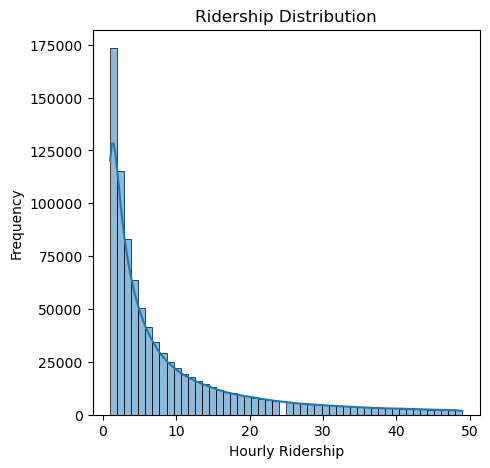

In [12]:
# data exploring
plt.figure(figsize=(5,5))
sns.histplot(df['ridership'], bins=50, kde=True)
plt.title("Ridership Distribution")
plt.xlabel("Hourly Ridership")
plt.ylabel("Frequency")
plt.show()

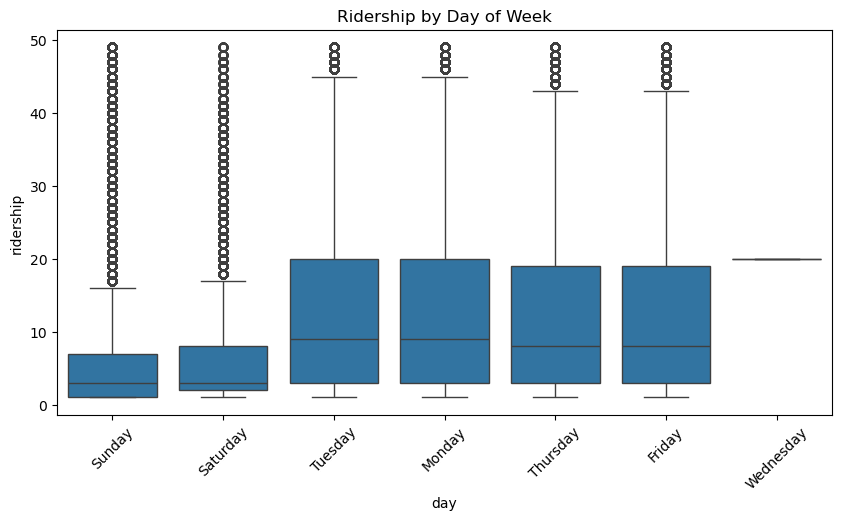

In [13]:
df['day'] = df['transit_timestamp'].dt.day_name()
plt.figure(figsize=(10,5))
sns.boxplot(x="day", y="ridership", data=df)
plt.title("Ridership by Day of Week")
plt.xticks(rotation=45)
plt.show()
# outliers are weird here. should I be cutting out >50 or no. maybe filter by just metro

In [14]:
print(df.columns)

Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude', 'day'],
      dtype='object')


In [15]:
# plot feature importance using built-in function
%pip install xgboost
from numpy import loadtxt
from xgboost import XGBRegressor
from xgboost import plot_importance
from matplotlib import pyplot


Note: you may need to restart the kernel to use updated packages.


/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [21:10:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.08467687609466924
              precision    recall  f1-score   support

           0      0.124     0.166     0.142      1383
           1      0.136     0.108     0.120       734
           2      0.175     0.198     0.186       683
           3      0.136     0.209     0.165       786
           4      0.115     0.174     0.139      1372
           5      0.097     0.100     0.098      2014
           6      0.083     0.062     0.071      2069
           7      0.097     0.102     0.099      1997
           8      0.087     0.095     0.091      1958
           9      0.081     0.056     0.066      2066
          10      0.070     0.043     0.054      2122
          11      0.074     0.046     0.057      2159
          12      0.056     0.038     0.045      2215
          13      0.063     0.083     0.072      2274
          14      0.069     0.105     0.083      2213
          15      0.079     0.109     0.091      2152
          16      0.067     0.078     0.072      21

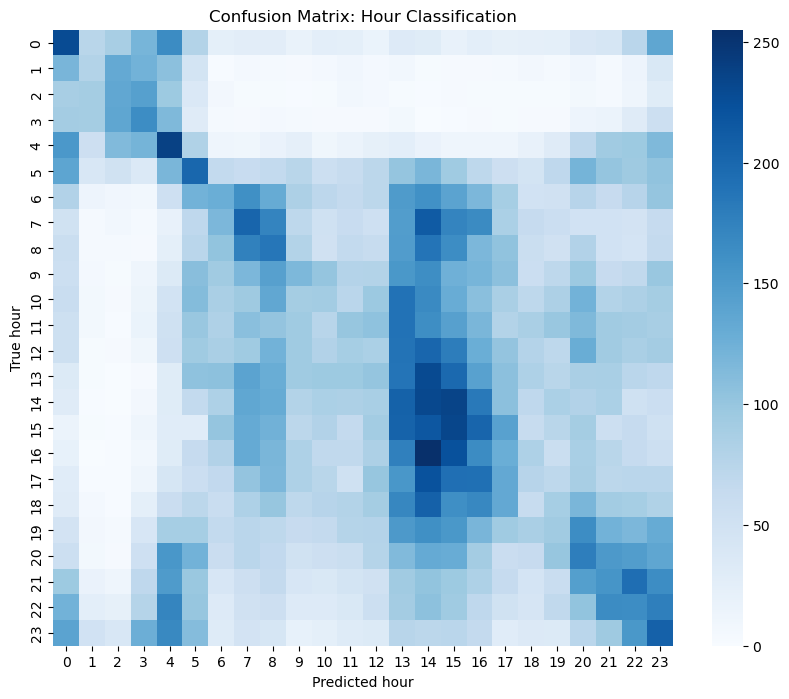

<Figure size 800x1000 with 0 Axes>

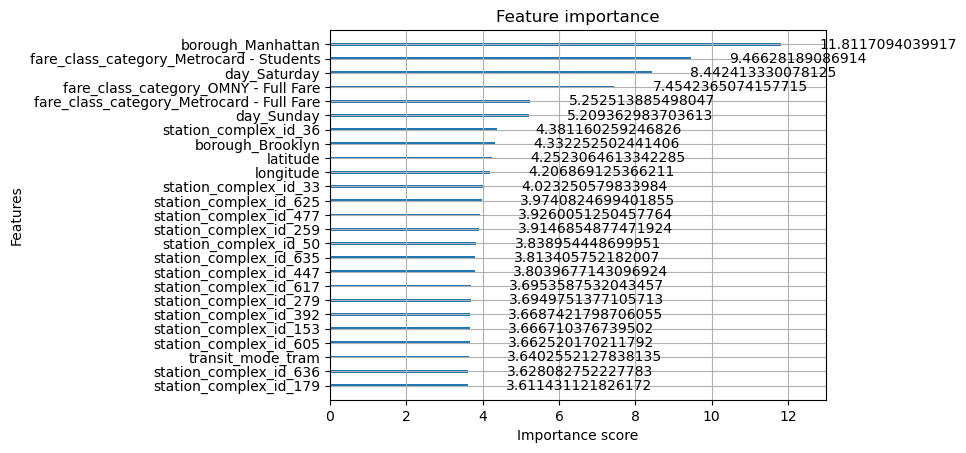

In [16]:
# classify hour of day (0-23) as target buckets
# prepare X and y
X = df.drop(columns=["transit_timestamp"])
y = df['transit_timestamp'].dt.hour  # labels 0..23

# one-hot encode categorical columns (keep numeric cols)
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# optional: subsample to speed up training (remove or reduce if you want full data)
sample_frac = 0.25
X_samp = X.sample(frac=sample_frac, random_state=42)
y_samp = y.loc[X_samp.index]

# train / test split (stratify to keep hour distribution)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_samp, y_samp, test_size=0.2, stratify=y_samp, random_state=42
)

# classifier
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = XGBClassifier(n_jobs=-1, random_state=42, use_label_encoder=False, eval_metric="mlogloss")
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# confusion matrix (visual)
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()), fmt="d")
plt.xlabel("Predicted hour")
plt.ylabel("True hour")
plt.title("Confusion Matrix: Hour Classification")
plt.show()

# feature importance (top 25)
plt.figure(figsize=(8,10))
plot_importance(model, max_num_features=25, importance_type="gain")
pyplot.show()
# ...existing code...

In [17]:
df["ridership"] = pd.to_numeric(df["ridership"], errors="coerce")

threshold = df["ridership"].quantile(0.75)
df["high_ridership"] = (df["ridership"] >= threshold).astype(int)

print("High-ridership threshold:", threshold)
print(df["high_ridership"].value_counts(normalize=True))

High-ridership threshold: 12.0
high_ridership
0    0.73823
1    0.26177
Name: proportion, dtype: float64


In [18]:
ts = pd.to_datetime(df["transit_timestamp"])

df["hour"] = ts.dt.hour
df["day_of_week"] = ts.dt.dayofweek
df["is_weekend"] = ts.dt.dayofweek.isin([5,6]).astype(int)

In [21]:
drop_cols = [
    "ridership",
    "transit_timestamp"
]

In [22]:
X = df.drop(columns=drop_cols + ["high_ridership"])
y = df["high_ridership"]

# convert numerics
for col in ["transfers", "latitude", "longitude"]:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# one-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [24]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [25]:
from sklearn.metrics import classification_report, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=3))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0      0.891     0.950     0.919    131506
           1      0.825     0.671     0.740     46631

    accuracy                          0.877    178137
   macro avg      0.858     0.810     0.830    178137
weighted avg      0.874     0.877     0.872    178137

ROC AUC: 0.9391598132726836
